Tick interval: 0.004
All plots will use the same tick interval but auto-scale to center on their data.

Generating Q1 vs Q4 comparison...


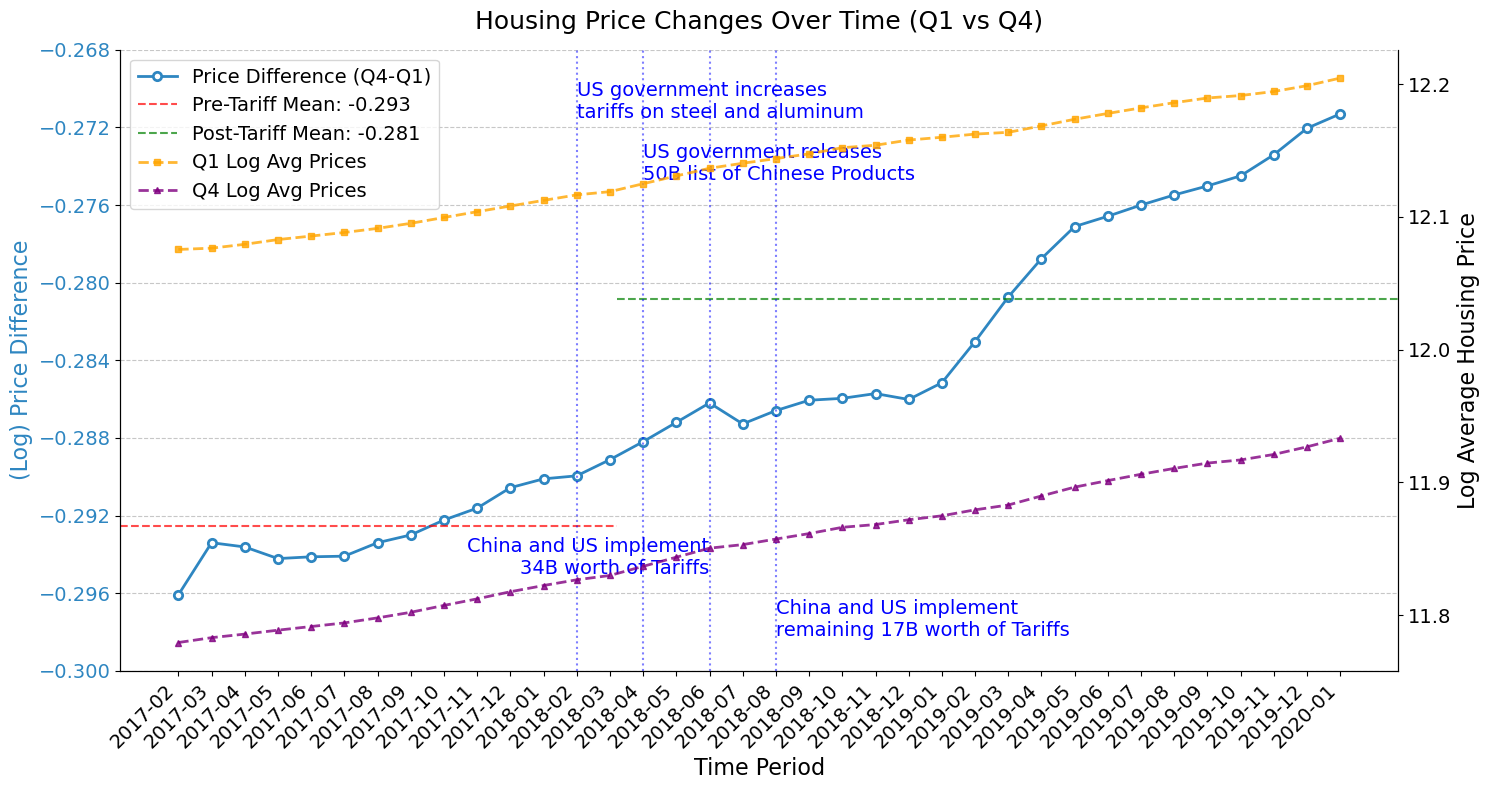

Plot saved as: images/housing_price_changes_q1_q4.png
Y-axis range: -0.3000 to -0.2680 with 0.004 intervals

Generating Q2 vs Q3 comparison...


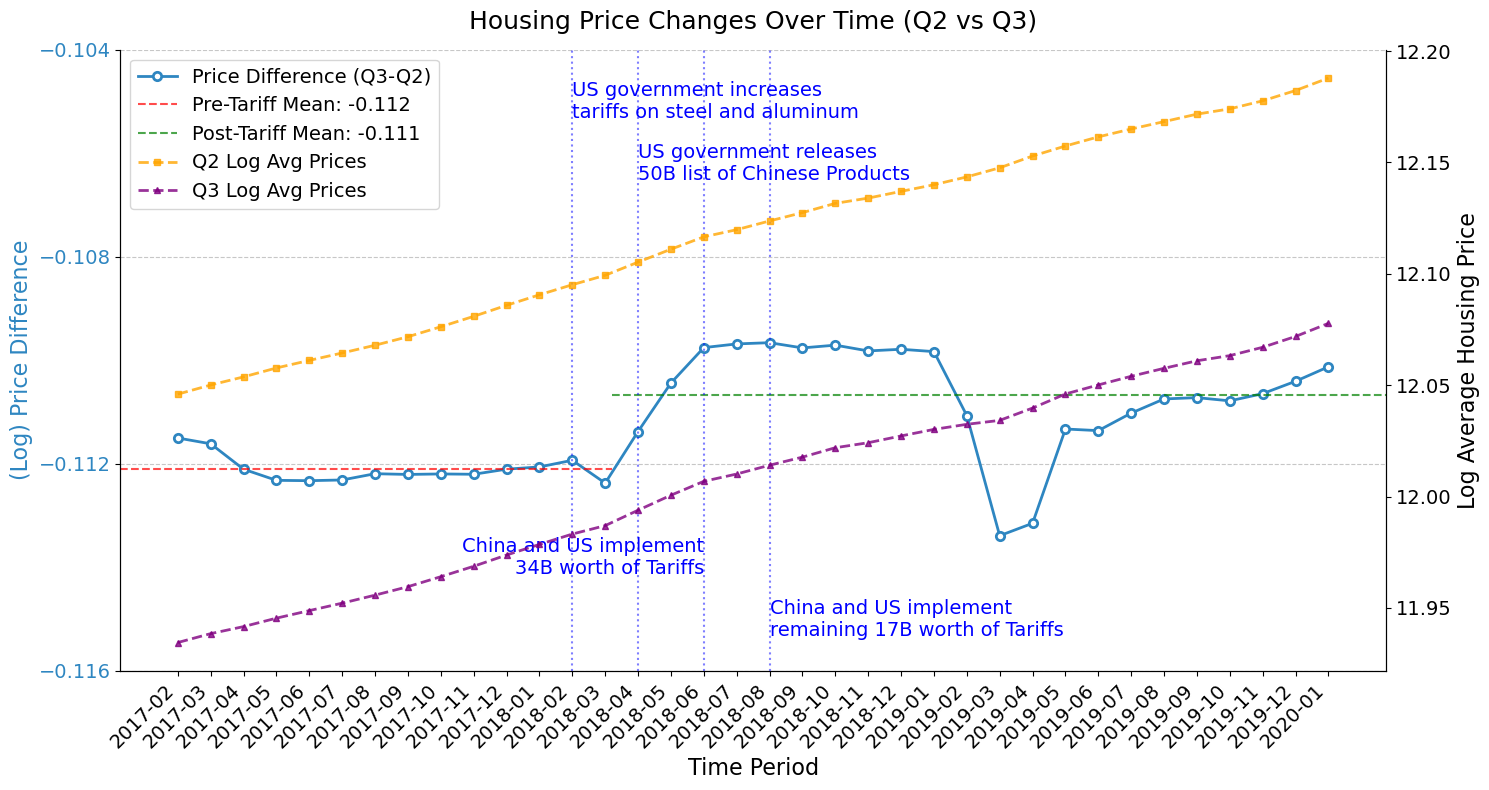

Plot saved as: images/housing_price_changes_q2_q3.png
Y-axis range: -0.1160 to -0.1040 with 0.004 intervals

Generating Q1 vs Q2 comparison...


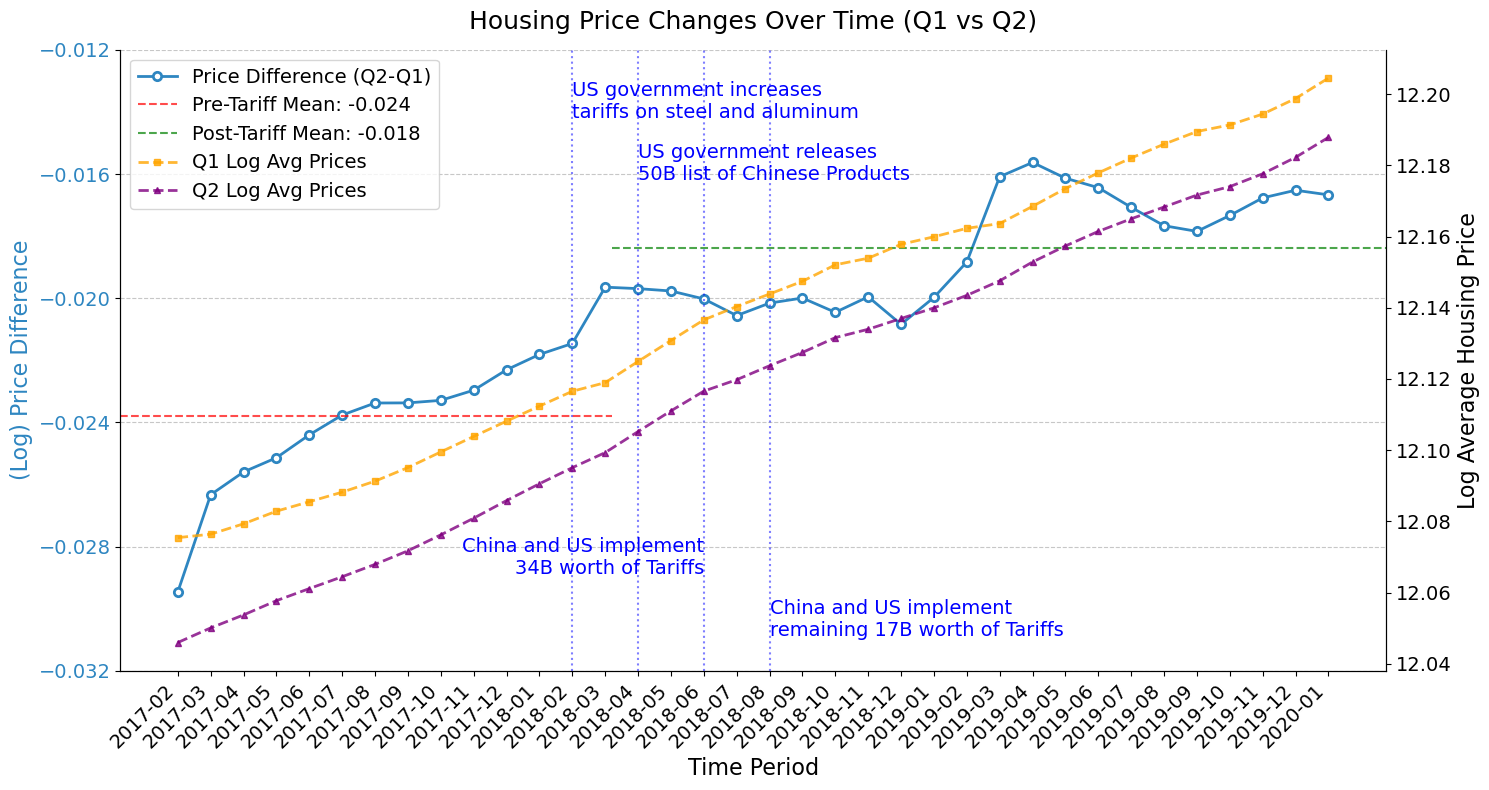

Plot saved as: images/housing_price_changes_q1_q2.png
Y-axis range: -0.0320 to -0.0120 with 0.004 intervals

Generating Q1 vs Q3 comparison...


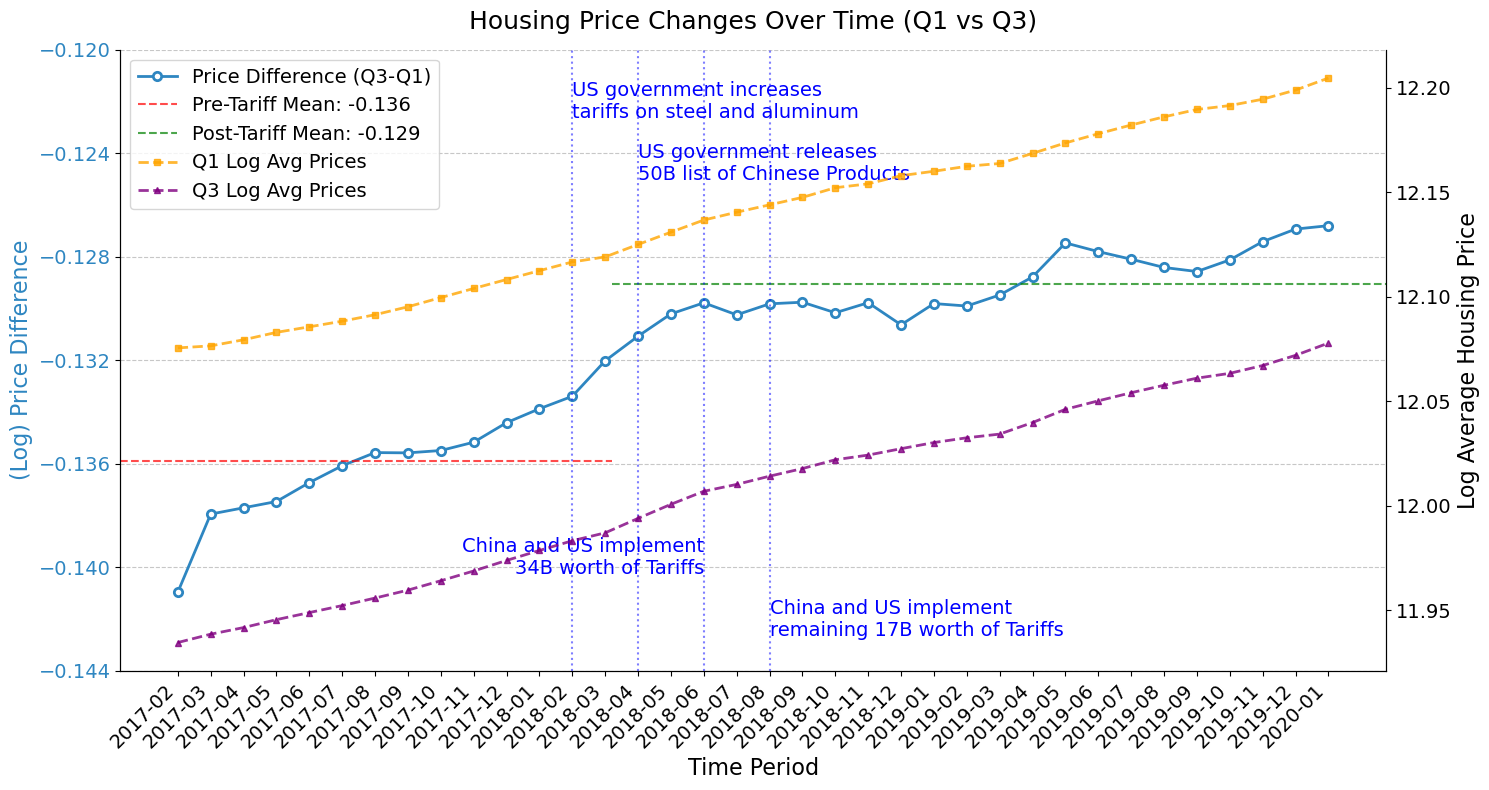

Plot saved as: images/housing_price_changes_q1_q3.png
Y-axis range: -0.1440 to -0.1200 with 0.004 intervals

All plots generated successfully with standardized tick intervals!
All plots use the same tick interval (0.004) but auto-scale to center on their data


In [7]:
#!/usr/bin/env python
# coding: utf-8

import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

# Read Zillow data
zillow = pd.read_csv('Data/zillow county.csv')

# Select and convert datetime columns
column_names_to_convert = zillow.columns[9:]
new_column_names = pd.to_datetime(column_names_to_convert)
zillow.columns = list(zillow.columns[:9]) + list(new_column_names)

# Drop columns outside the desired year range (2017-2019)
for column in new_column_names:
    column_year = column.year
    if not (2017 <= column_year <= 2019):
        zillow = zillow.drop(columns=[column])

# Make county FIPS column
zillow['CountyFIPS'] = (
    zillow['StateCodeFIPS'].astype(str).str.zfill(2) + 
    zillow['MunicipalCodeFIPS'].astype(str).str.zfill(3)
)

# Read tariff data
tariffs = pd.read_csv('Data/ustariffs-by-county.csv')

# Clean tariff data
tariffs_clean = tariffs.drop(columns=['Unnamed: 0','emplvl_2017', 'fips', 'total_employment', 'int_area_fips',
       '2017_income', '2017_population', 'total_imp_pc', 'china_imp_pc'])

# Filter for years and clean area_fips
tariffs_clean['time'] = pd.to_datetime(tariffs_clean['time'])
tariffs_clean = tariffs_clean[(tariffs_clean['time'].dt.year >= 2017) & (tariffs_clean['time'].dt.year <= 2019)]
tariffs_clean['area_fips'] = tariffs_clean['area_fips'].astype(str).str.zfill(5)
tariffs_clean = tariffs_clean[~tariffs_clean['area_fips'].astype(str).str.endswith('999')]
tariffs_clean = tariffs_clean[tariffs_clean['time'] != '2017-01-01 00:00:00']
if 'state' in tariffs_clean.columns:
    tariffs_clean = tariffs_clean.drop('state', axis=1)
tariffs_clean = tariffs_clean.reset_index(drop=True)

# Pivot tariff data and calculate change
tariffs_clean_pivoted = tariffs_clean.pivot(index='area_fips', columns='time', values='tariff')
tariffs_clean_pivoted = tariffs_clean_pivoted.reset_index()
tariffs_clean_pivoted['change'] = tariffs_clean_pivoted.iloc[:,-1] - tariffs_clean_pivoted.iloc[:,1]
tariffs_clean_pivoted = tariffs_clean_pivoted.sort_values(by=['change'], ascending=False)
tariffs_clean_pivoted = tariffs_clean_pivoted.reset_index(drop=True)
tariffs_clean_pivoted = tariffs_clean_pivoted.dropna()

# Create quartiles based on tariff changes
tariffs_clean_pivoted['quartile'] = pd.qcut(tariffs_clean_pivoted['change'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Get all quartiles
q1 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q1']
q2 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q2']
q3 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q3']
q4 = tariffs_clean_pivoted[tariffs_clean_pivoted['quartile'] == 'Q4']

# Clean data columns to drop
drop_columns = ['Metro','StateCodeFIPS','MunicipalCodeFIPS','State','StateName','RegionType','RegionName','SizeRank','RegionID','CountyFIPS']

# Set consistent tick interval
tick_interval = 0.004  # This creates intervals of 0.004

# Function to create quartile comparison plot with standardized y-axis
def create_quartile_plot(q_high, q_low, q_high_name, q_low_name, title_suffix, filename):
    # Filter Zillow data for the quartiles
    zillow_high_tariffs = zillow[zillow['CountyFIPS'].isin(q_high['area_fips'])]
    zillow_low_tariffs = zillow[zillow['CountyFIPS'].isin(q_low['area_fips'])]
    
    # Clean data and calculate means
    zillow_high_clean = zillow_high_tariffs.drop(columns=drop_columns)
    zillow_low_clean = zillow_low_tariffs.drop(columns=drop_columns)
    
    # Calculate log means for both difference and individual quartiles
    zillow_high_log_mean = pd.DataFrame([np.log(zillow_high_clean.mean())])
    zillow_low_log_mean = pd.DataFrame([np.log(zillow_low_clean.mean())])
    diff = zillow_high_log_mean - zillow_low_log_mean
    
    # Calculate averages before and after the split date
    split_date = pd.Timestamp('2018-02-28')
    before_mask = diff.columns <= split_date
    after_mask = diff.columns > split_date
    before_mean = diff.iloc[0, before_mask].mean()
    after_mean = diff.iloc[0, after_mask].mean()
    
    # Create the plot with dual y-axes
    fig, ax1 = plt.subplots(figsize=(15, 8))
    
    # Convert dates to month format and shift them forward by one month for x-axis
    x_dates = [(d + pd.DateOffset(months=1)).strftime('%Y-%m') for d in diff.columns]
    
    # Main line plot (price difference) on left y-axis
    ax1.plot(x_dates, diff.iloc[0], 
             marker='o', 
             linewidth=2, 
             markersize=6,
             color='#2E86C1',
             linestyle='-',
             markerfacecolor='white',
             markeredgewidth=2,
             label=f'Price Difference ({q_high_name}-{q_low_name})')
    
    # Let matplotlib auto-scale the y-axis but set consistent tick intervals
    # Get the auto-scaled y-axis limits
    plt.draw()  # Force a draw to get the auto-scaled limits
    y_min, y_max = ax1.get_ylim()
    
    # Create ticks with consistent intervals centered around the data
    y_ticks = np.arange(np.floor(y_min/tick_interval)*tick_interval, 
                        np.ceil(y_max/tick_interval)*tick_interval + tick_interval, 
                        tick_interval)
    ax1.set_yticks(y_ticks)
    
    # Create second y-axis for log average housing prices
    ax2 = ax1.twinx()
    
    # Plot log mean prices for both quartiles on right y-axis
    ax2.plot(x_dates, zillow_low_log_mean.iloc[0].values, 
             marker='s', 
             linewidth=2, 
             markersize=5,
             color='orange',
             linestyle='--',
             alpha=0.8,
             label=f'{q_low_name} Log Avg Prices')
    
    ax2.plot(x_dates, zillow_high_log_mean.iloc[0].values, 
             marker='^', 
             linewidth=2, 
             markersize=5,
             color='purple',
             linestyle='--',
             alpha=0.8,
             label=f'{q_high_name} Log Avg Prices')
    
    # Add horizontal mean lines for price difference (left axis)
    ax1.axhline(y=before_mean, color='r', linestyle='--', alpha=0.7, 
               xmin=0, xmax=len(before_mask[before_mask])/len(diff.columns),
               label=f'Pre-Tariff Mean: {before_mean:.3f}')
    ax1.axhline(y=after_mean, color='g', linestyle='--', alpha=0.7,
               xmin=len(before_mask[before_mask])/len(diff.columns), xmax=1,
               label=f'Post-Tariff Mean: {after_mean:.3f}')
    
    # Use the auto-scaled y-axis range for positioning text
    y_min, y_max = ax1.get_ylim()
    y_range = y_max - y_min
    
    # Add line for steel and aluminum tariff announcement
    steel_date = pd.Timestamp('2018-01-31')
    shifted_steel_date = (steel_date + pd.DateOffset(months=1)).strftime('%Y-%m')
    ax1.axvline(x=shifted_steel_date, color='blue', linestyle=':', alpha=0.5)
    ax1.text(shifted_steel_date, y_max - 0.05 * y_range, 
             'US government increases\ntariffs on steel and aluminum',
             verticalalignment='top',
             horizontalalignment='left',
             color='blue',
             fontsize=14)
    
    # Add line for releasing list
    list_date = pd.Timestamp('2018-03-31')
    shifted_list_date = (list_date + pd.DateOffset(months=1)).strftime('%Y-%m')
    ax1.axvline(x=shifted_list_date, color='blue', linestyle=':', alpha=0.5)
    ax1.text(shifted_list_date, y_max - 0.15 * y_range, 
             'US government releases\n50B list of Chinese Products',
             verticalalignment='top',
             horizontalalignment='left',
             color='blue',
             fontsize=14)
    
    # Add line for implementation date
    tariff_date = pd.Timestamp('2018-05-31')
    shifted_tariff_date = (tariff_date + pd.DateOffset(months=1)).strftime('%Y-%m')
    ax1.axvline(x=shifted_tariff_date, color='blue', linestyle=':', alpha=0.5)
    ax1.text(shifted_tariff_date, y_min + 0.15 * y_range, 
             'China and US implement\n34B worth of Tariffs',
             verticalalignment='bottom',
             horizontalalignment='right',
             color='blue',
             fontsize=14)
    
    tariff_date2 = pd.Timestamp('2018-07-31')
    shifted_tariff_date2 = (tariff_date2 + pd.DateOffset(months=1)).strftime('%Y-%m')
    ax1.axvline(x=shifted_tariff_date2, color='blue', linestyle=':', alpha=0.5)
    ax1.text(shifted_tariff_date2, y_min + 0.05 * y_range, 
             'China and US implement\nremaining 17B worth of Tariffs',
             verticalalignment='bottom',
             horizontalalignment='left',
             color='blue',
             fontsize=14)
    
    # Improve grid and formatting
    ax1.grid(True, linestyle='--', alpha=0.7, axis='y')
    ax1.set_title(f'Housing Price Changes Over Time ({title_suffix})', fontsize=18, pad=15)
    ax1.set_xlabel('Time Period', fontsize=16)
    ax1.set_ylabel('(Log) Price Difference', fontsize=16, color='#2E86C1')
    ax2.set_ylabel('Log Average Housing Price', fontsize=16, color='black')
    
    # Format x-axis with larger tick labels
    ax1.tick_params(axis='x', rotation=45, labelsize=14)
    ax1.tick_params(axis='y', labelcolor='#2E86C1', labelsize=14)
    ax2.tick_params(axis='y', labelcolor='black', labelsize=14)
    plt.setp(ax1.xaxis.get_majorticklabels(), ha='right')
    
    # Combine legends from both axes with larger font
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, 
               labels1 + labels2,
               loc='upper left',
               fontsize=14)
    
    # Remove top and right borders for both axes
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    
    # Clean up layout
    fig.tight_layout()
    
    # Save the figure
    plt.savefig(f'images/{filename}', 
                dpi=300,
                bbox_inches='tight',
                facecolor='white',
                format='png')
    
    # Show the plot
    plt.show()
    
    print(f"Plot saved as: images/{filename}")
    print(f"Y-axis range: {y_min:.4f} to {y_max:.4f} with {tick_interval} intervals")

# Print tick interval information
print(f"Tick interval: {tick_interval}")
print(f"All plots will use the same tick interval but auto-scale to center on their data.\n")

# Generate all four quartile comparison plots with standardized y-axis
print("Generating Q1 vs Q4 comparison...")
create_quartile_plot(q4, q1, 'Q4', 'Q1', 'Q1 vs Q4', 'housing_price_changes_q1_q4.png')

print("\nGenerating Q2 vs Q3 comparison...")
create_quartile_plot(q3, q2, 'Q3', 'Q2', 'Q2 vs Q3', 'housing_price_changes_q2_q3.png')

print("\nGenerating Q1 vs Q2 comparison...")
create_quartile_plot(q2, q1, 'Q2', 'Q1', 'Q1 vs Q2', 'housing_price_changes_q1_q2.png')

print("\nGenerating Q1 vs Q3 comparison...")
create_quartile_plot(q3, q1, 'Q3', 'Q1', 'Q1 vs Q3', 'housing_price_changes_q1_q3.png')

print("\nAll plots generated successfully with standardized tick intervals!")
print(f"All plots use the same tick interval ({tick_interval}) but auto-scale to center on their data")